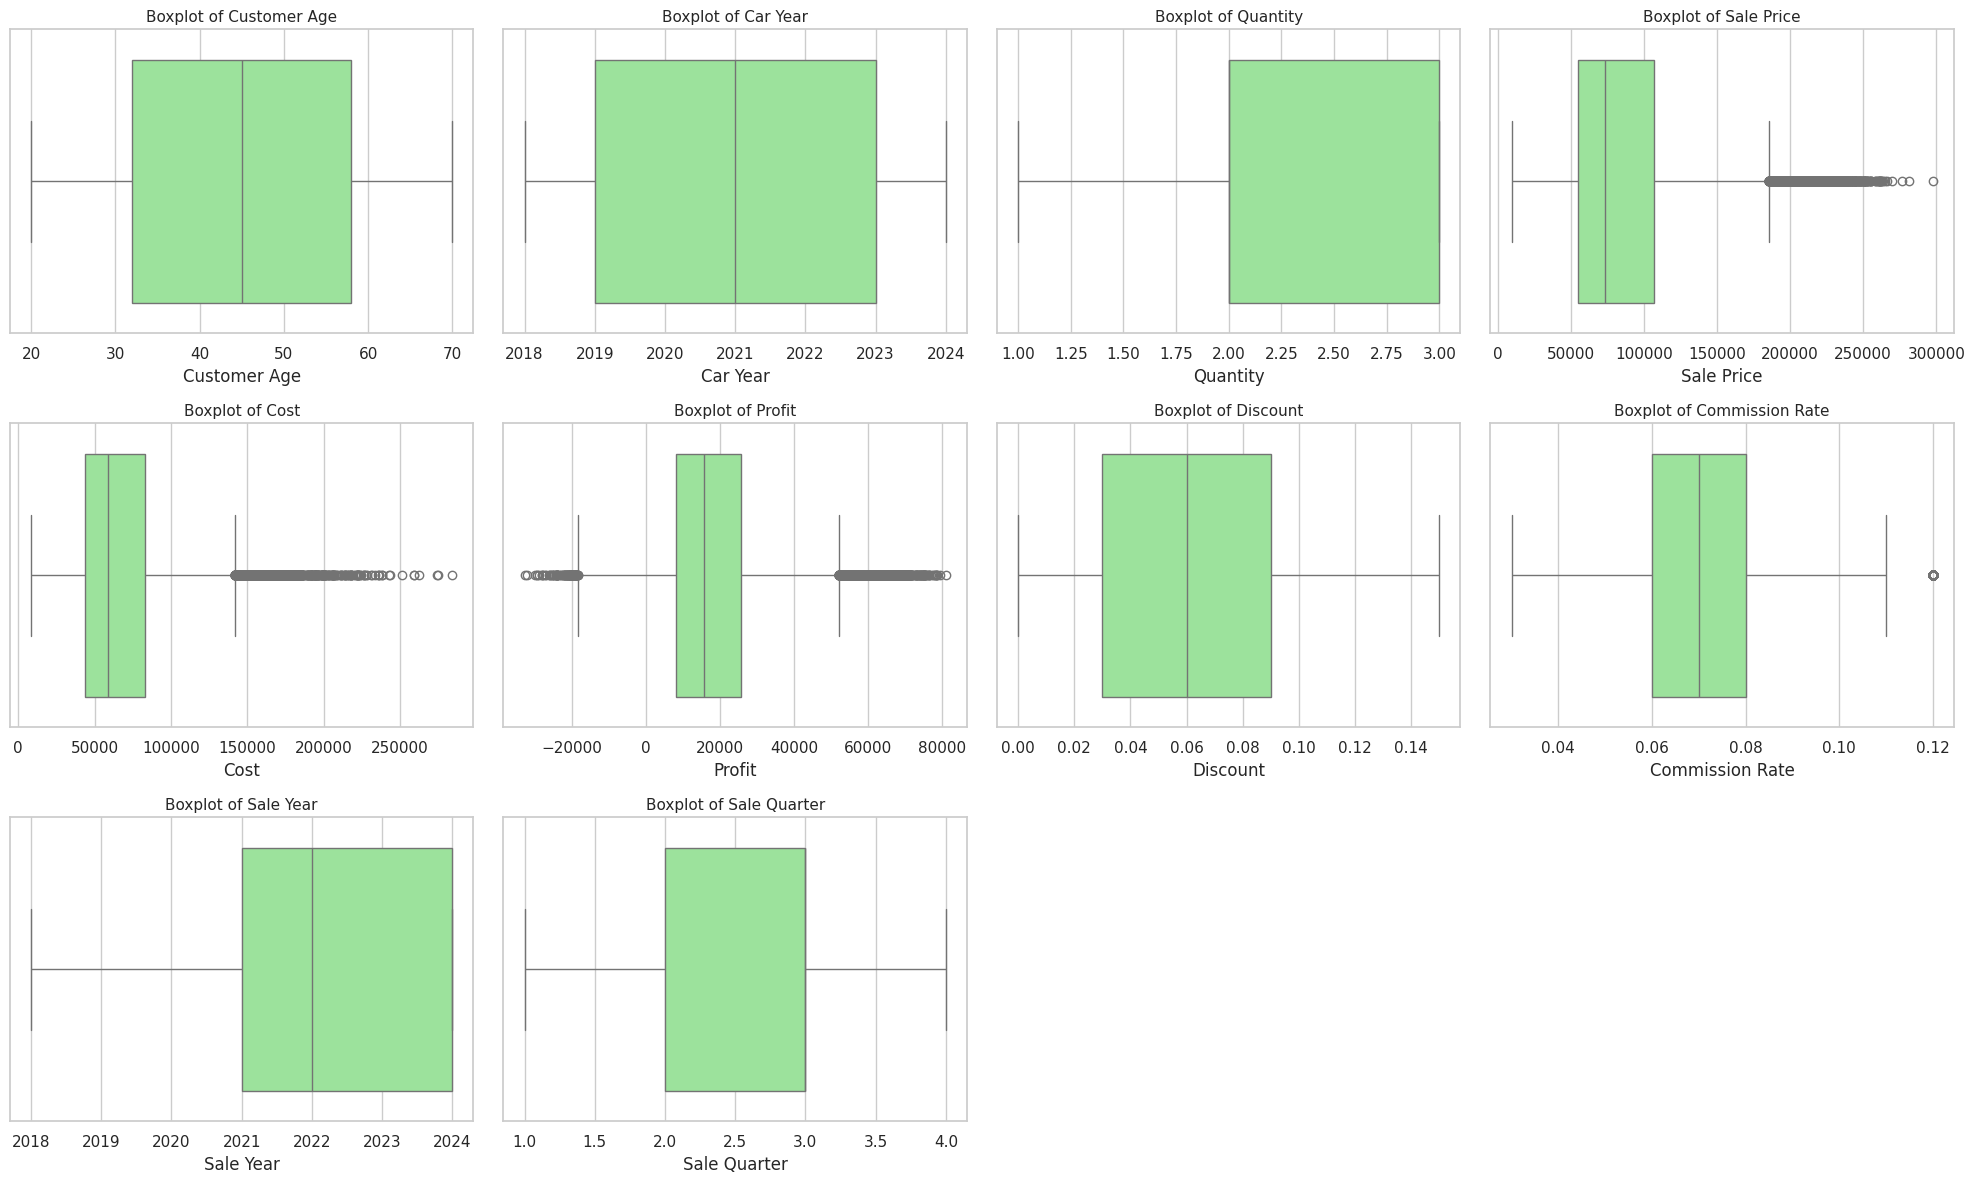

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))

for i, col in enumerate(num_features):
    ax = axes[i // 4, i % 4]
    sns.boxplot(x=data[col], color="lightgreen", ax=ax)
    ax.set_title(f"Boxplot of {col}", fontsize=11)
    ax.set_xlabel(col)

# Hide unused axes
for j in range(len(num_features), 12):
    fig.delaxes(axes[j // 4, j % 4])

plt.tight_layout()
plt.show()


#### Correlation and Multicollinearity

<Axes: xlabel='Car Make', ylabel='Sale Price'>

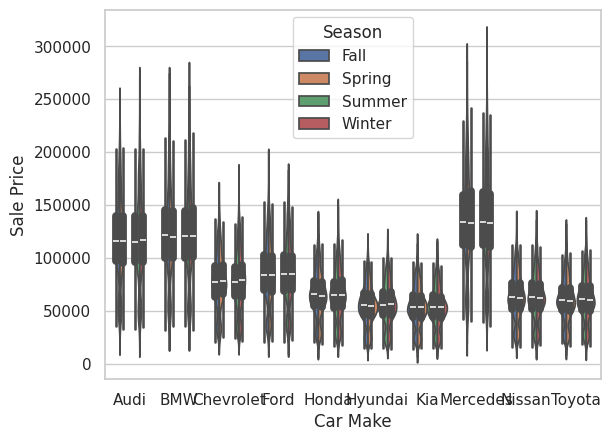

In [ ]:
sns.violinplot(x='Car Make', y='Sale Price', hue='Season', data=data, split=True)


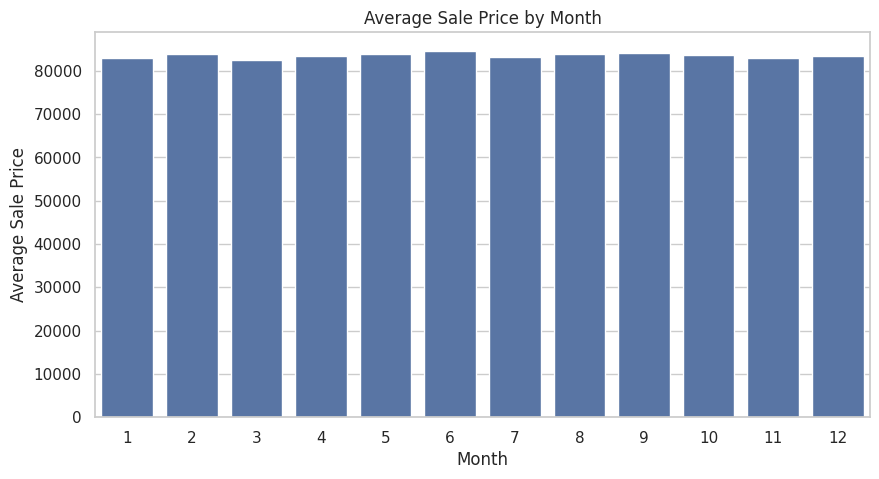

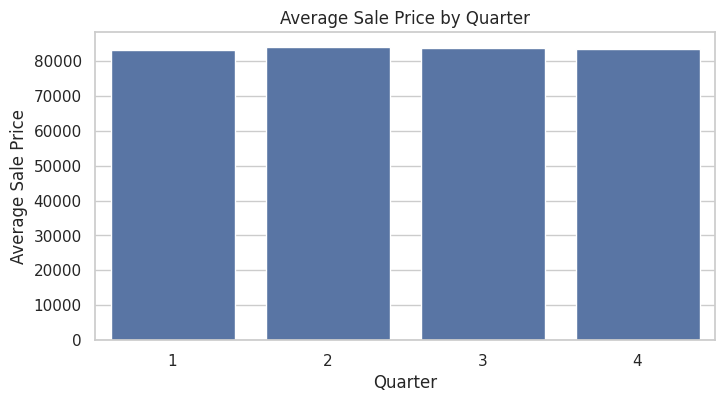

In [ ]:
# Monthly seasonality
monthly_avg = data.groupby(data['Date'].dt.month)['Sale Price'].mean()
plt.figure(figsize=(10,5))
sns.barplot(x=monthly_avg.index, y=monthly_avg.values)
plt.title('Average Sale Price by Month')
plt.xlabel('Month')
plt.ylabel('Average Sale Price')
plt.show()

# Quarterly seasonality
quarterly_avg = data.groupby(data['Date'].dt.quarter)['Sale Price'].mean()
plt.figure(figsize=(8,4))
sns.barplot(x=quarterly_avg.index, y=quarterly_avg.values)
plt.title('Average Sale Price by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Average Sale Price')
plt.show()


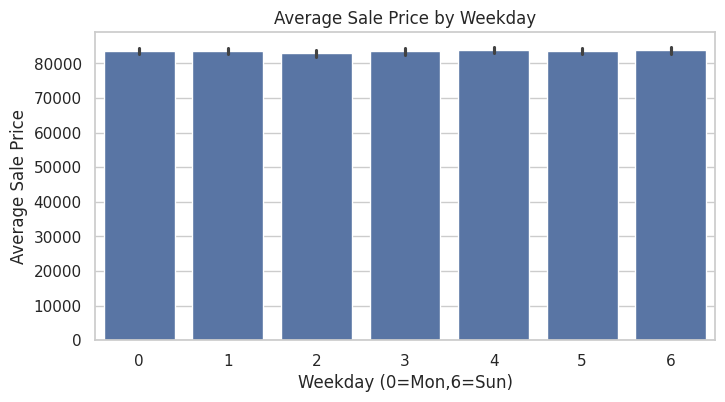

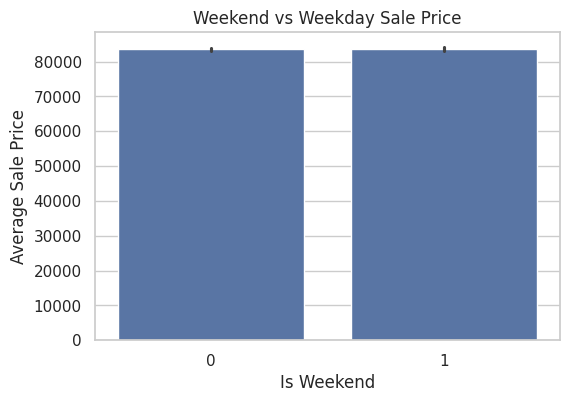

In [ ]:
data['Weekday'] = data['Date'].dt.weekday
data['Is_Weekend'] = data['Weekday'].isin([5,6]).astype(int)

plt.figure(figsize=(8,4))
sns.barplot(x='Weekday', y='Sale Price', data=data)
plt.title('Average Sale Price by Weekday')
plt.xlabel('Weekday (0=Mon,6=Sun)')
plt.ylabel('Average Sale Price')
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(x='Is_Weekend', y='Sale Price', data=data)
plt.title('Weekend vs Weekday Sale Price')
plt.xlabel('Is Weekend')
plt.ylabel('Average Sale Price')
plt.show()


In [ ]:
#### . Seasonal Decomposition

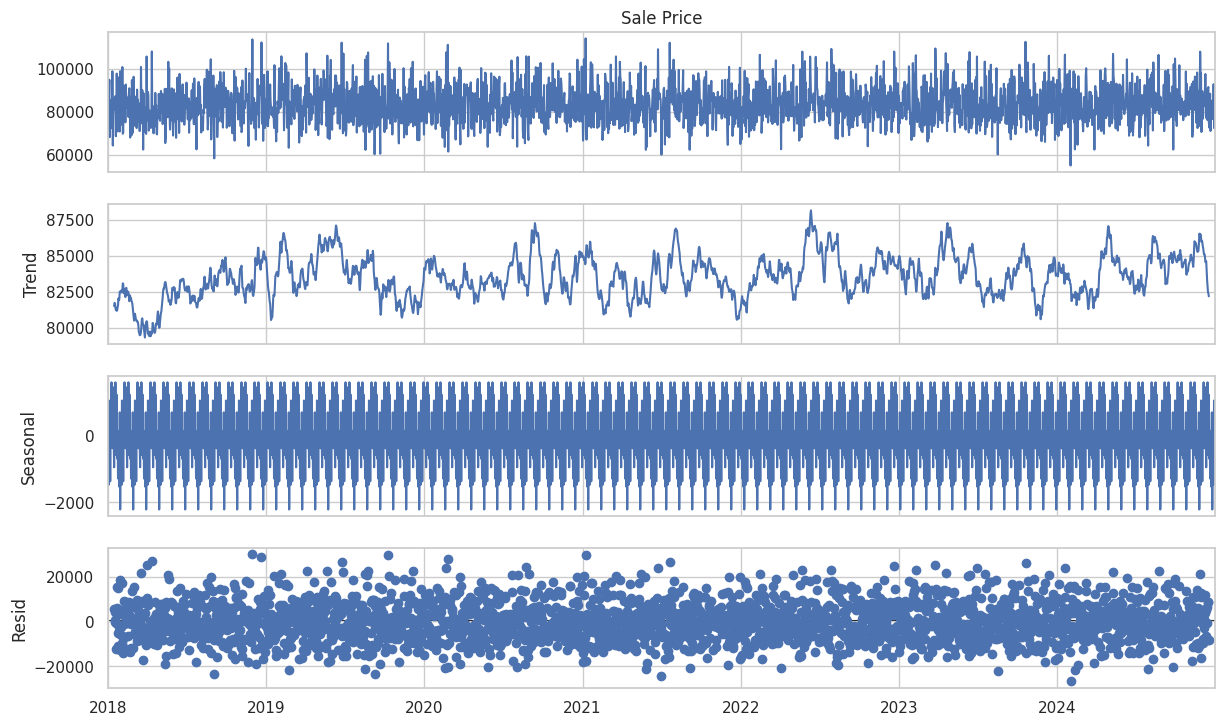

In [ ]:
data['Date'] = pd.to_datetime(data['Date'])

# Daily aggregation
ts = data.groupby('Date')['Sale Price'].mean()

# Seasonal decomposition
decomposition = sm.tsa.seasonal_decompose(ts, model='additive', period=30)
fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.show()



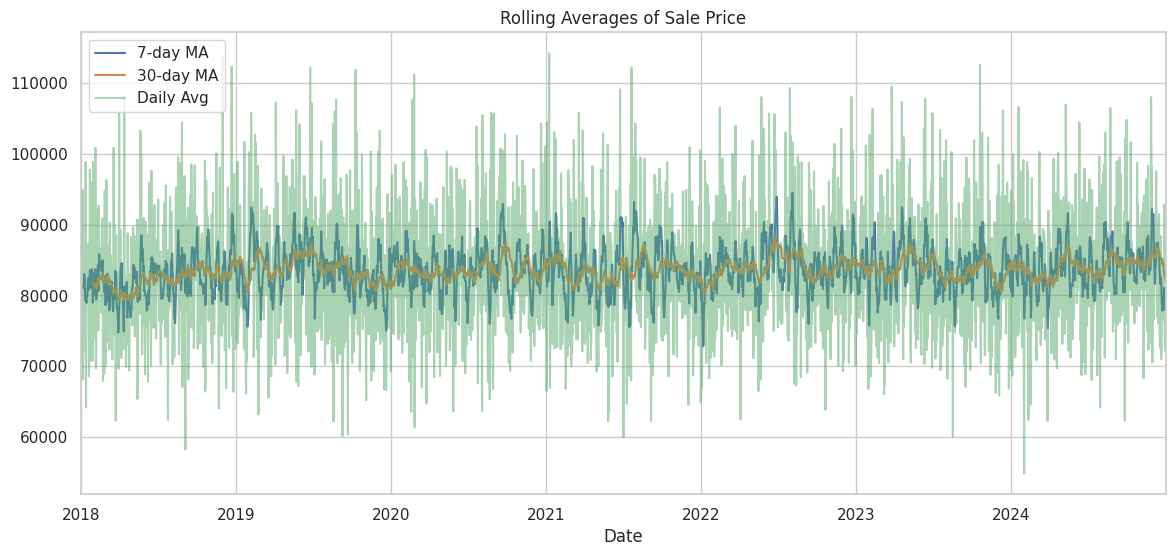

In [ ]:
plt.figure(figsize=(14,6))
ts.rolling(window=7).mean().plot(label='7-day MA')
ts.rolling(window=30).mean().plot(label='30-day MA')
ts.plot(alpha=0.5, label='Daily Avg')
plt.title('Rolling Averages of Sale Price')
plt.legend()
plt.show()
